In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import normaltest
import os
from pathlib import Path
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#%mldev import

/Users/andrey/MIPT_projects/2023-project-119


In [5]:
print("Staprting Normality_and_Hist.ipynb ...")
#%mldev start

Staprting Normality_and_Hist.ipynb ...


```yaml

#%mldev nb_context

Normality_and_Hist:
  - import
  - start
  - experiment_mode
  - paths
  - rc
  - make_p_value_plot
  - make_hist
  - sliding_window_setup
  - sampling_update_setup
```

In [34]:
experiment_mode = 'mldev'
#%mldev experiment_mode

In [41]:
# run this cell if you are in Jupyter and not running the notebook with mldev
experiment_mode = 'jupyter'

In [35]:
path_loop = os.getenv("MLDEV_DELTA_LOOP_PATH", default="results/hidden-loop_delta")
path_sample = os.getenv("MLDEV_DELTA_SAMPLE_PATH", default="results/hidden-sample_delta")
save_path = os.getenv("MLDEV_SAVEFIGURES_PATH", default="figures")
os.makedirs(save_path, exist_ok=True)
#%mldev paths

In [36]:
plt.rc('axes', titlesize=25, titleweight='bold') #fontsize of the title
plt.rc('axes', labelsize=20) #fontsize of the x and y labels
plt.rc('xtick', labelsize=20) #fontsize of the x tick labels
plt.rc('ytick', labelsize=20) #fontsize of the y tick labels
plt.rc('legend', fontsize=25) #fontsize of the legend
plt.rc('figure', figsize=(12, 8)) # figure size
#%mldev rc

In [37]:
def make_p_value_plot(path, experiment_name='sliding_window', 
                      usage=1, adherence=0, run_times=10, model_name='sgd_model_50',
                      dataset_name='synthetic', experiment_mode='jupyter'):
    ### preparing our data ###
    directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/0")
    steps = []
    for file in directory.iterdir():
        if file.name != '.DS_Store':
            steps.append(int(file.name.split('_')[-1].split('.')[0]))
    steps = sorted(steps)[:1001]
    p_values = []
    for trial in range(run_times):
        for step in steps:
            directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/{trial}")
            data = pd.read_csv(f"{directory}/dev_step_{step}.csv")
            _, p_value = normaltest(data['y'] - data['y_pred'])
            p_values.append(p_value)
    
    p_values = np.array(p_values)
    
    ### make hist ###
    plt.title(f"usage={usage}, adherence={adherence}")

    plt.xlabel(r"step $t$")
    plt.ylabel(r"$p$-value")

    sns.lineplot(x=steps*run_times, y=p_values, label="p_values",
                 color="blue", marker=None, markersize=5)
    plt.plot(steps, [0.05]*len(steps), '--', color="red", label="p_value = 0.05")

    plt.legend()
    plt.grid()
    plt.tight_layout()

    if experiment_mode == 'jupyter':
        plt.show()
    elif experiment_mode == 'mldev':
        plt.savefig(f"{save_path}/p_{experiment_name}_{dataset_name}_{model_name}_{usage}_{adherence}.png")
        plt.close()
    else:
        raise ValueError(f"Wrong experiment mode {experiment_mode}!")
#%mldev make_p_value_plot

In [38]:
def make_hist(path, steps_hist, xlim=0.5, bins=20, experiment_name='sliding_window',
              model_name='sgd_model_50', dataset_name='synthetic',
              usage=1.0, adherence=0.0, run_times=10, experiment_mode='jupyter'):
    plt.title(f"usage={usage}, adherence={adherence}")
    plt.xlabel(r"$y - y_{pred}$")
    plt.ylabel("Density")
    plt.xlim((-xlim, xlim))

    colors = ['red', 'green', 'blue', 'orange', 'purple',
              'cyan', 'pink', 'brown', 'black', 'olive']
    data_hist = {}
    for step in steps_hist:
        data_hist[f"t = {step}"] = []
    for trial in range(run_times):
        for step in steps_hist:
            directory = Path(f"{path}/{adherence}-{usage}/{dataset_name}/{model_name}/{trial}")
            data = pd.read_csv(f"{directory}/dev_step_{step}.csv")
            data_hist[f"t = {step}"] += list(data['y'] - data['y_pred'])
    for key, color in zip(data_hist.keys(), colors):
        sns.histplot(data_hist[key], stat='density', color=color, label=key, bins=bins)
    #for step, color in enumerate(zip(steps_hist, colors)):
    #    sns.histplot(data_hist[i], bins=bins, label=f"t = {step}", color=color,
    #                 density=True, stacked=True)

    plt.legend()
    plt.grid()
    plt.tight_layout()
    if experiment_mode == 'jupyter':
        plt.show()
    elif experiment_mode == 'mldev':
        plt.savefig(f"{save_path}/hist_{experiment_name}_{dataset_name}_{model_name}_{usage}_{adherence}.png")
        plt.close()
    else:
        raise ValueError(f"Wrong experiment mode {experiment_mode}!")
#%mldev make_hist

## Sliding window setup

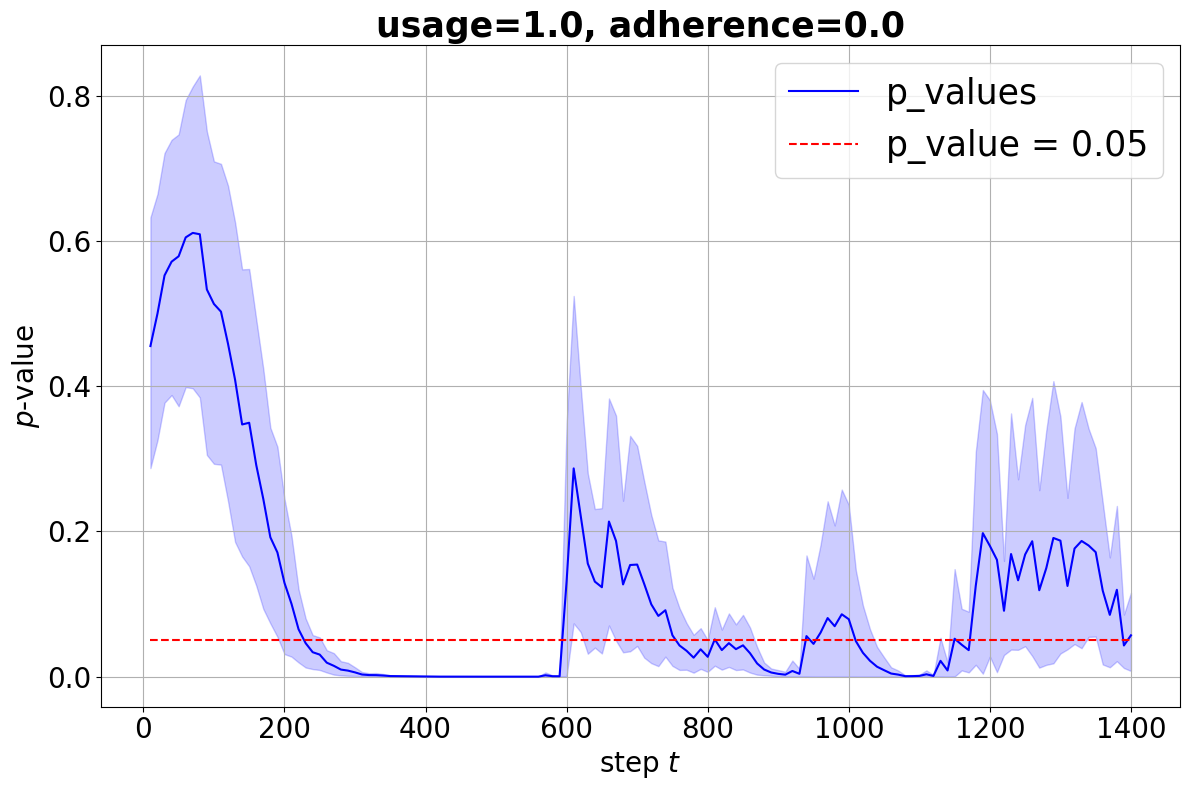

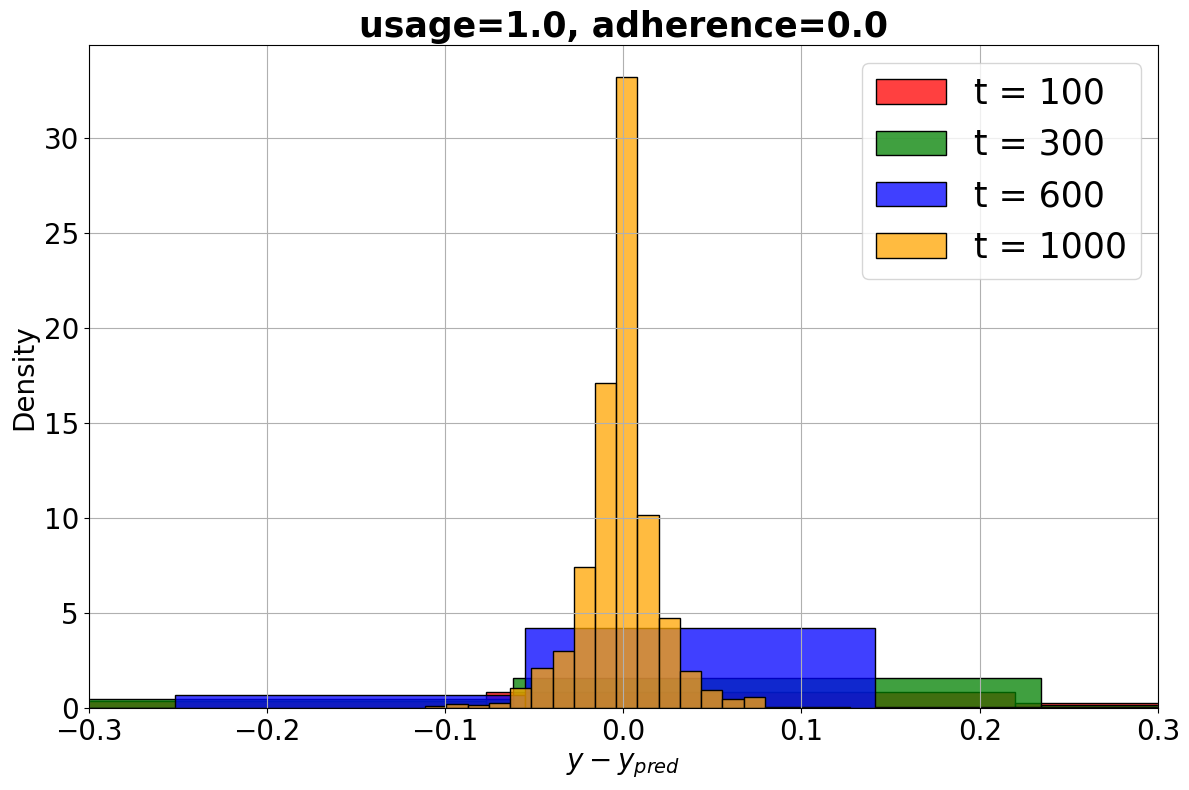

In [42]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
make_p_value_plot(path=path_loop, experiment_name='sw', 
                  usage=1.0, adherence=0.0, model_name=model_name,
                  dataset_name=dataset_name, run_times=10, 
                  experiment_mode=experiment_mode)
make_hist(path=path_loop, steps_hist=[100, 300, 600, 1000],
          xlim=0.3, bins=20, experiment_name='sw', model_name=model_name,
          usage=1.0, adherence=0.0, run_times=10, dataset_name=dataset_name,
          experiment_mode=experiment_mode)
#%mldev sliding_window_setup

## Sampling update setup

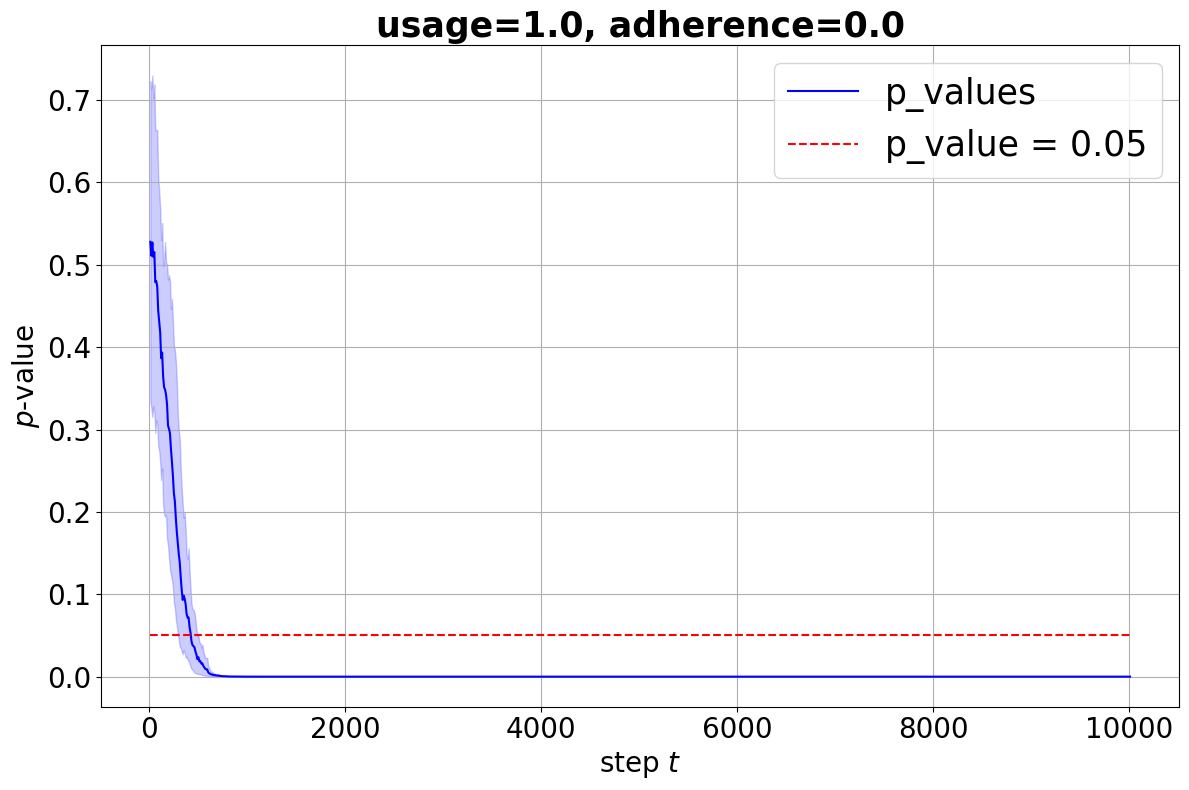

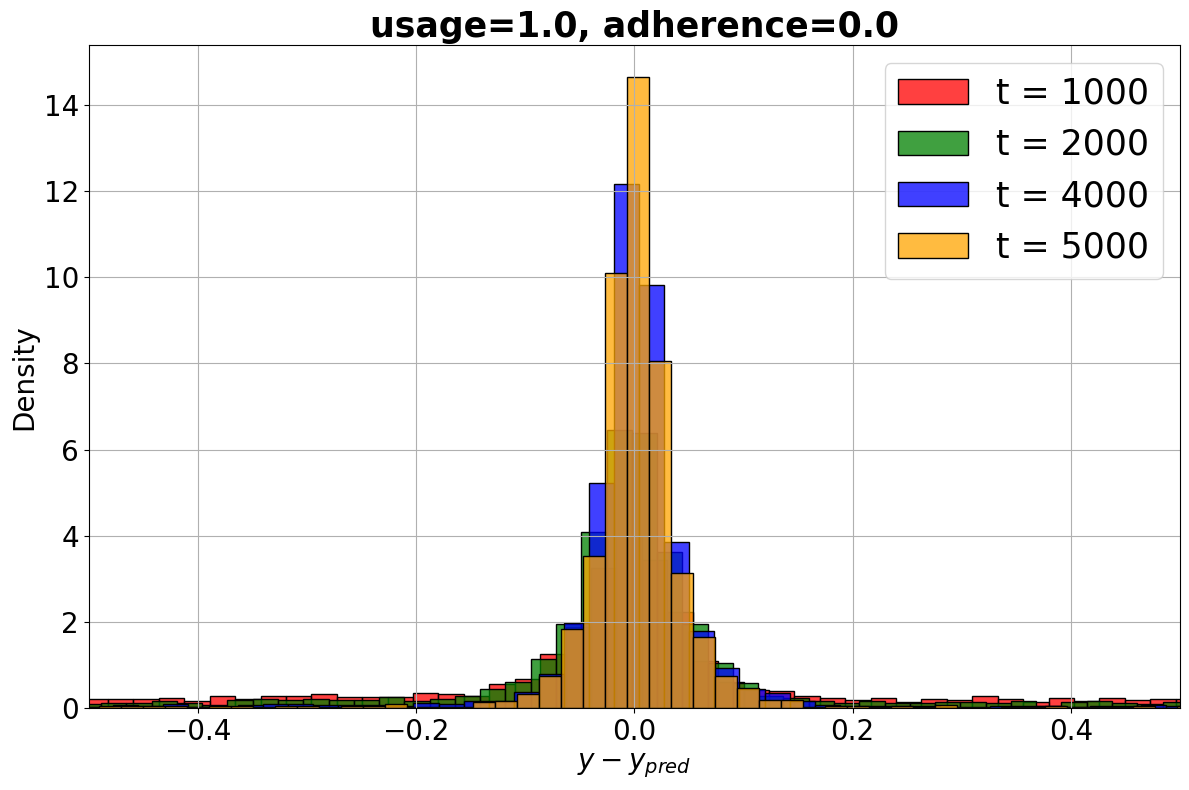

In [43]:
model_name = 'sgd_model_50'
dataset_name = 'synthetic'
make_p_value_plot(path=path_sample, experiment_name='su', 
                  usage=1.0, adherence=0.0, model_name=model_name,
                  dataset_name=dataset_name,run_times=10, 
                  experiment_mode=experiment_mode)
make_hist(path=path_sample, steps_hist=[1000, 2000, 4000, 5000],
          xlim=0.5, bins=300, experiment_name='su',
          model_name=model_name, dataset_name=dataset_name,
          usage=1.0, adherence=0.0, run_times=10,
          experiment_mode=experiment_mode)
#%mldev sampling_update_setup